In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import astropy.units as u

print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("scipy:", np.__version__)
print("astropy:", u.__version__ if hasattr(u, '__version__') else "ok")
print("\nAll good — ready to build GalacticMergerSim 🚀")

numpy: 2.4.6
matplotlib: 3.10.9
scipy: 2.4.6
astropy: ok

All good — ready to build GalacticMergerSim 🚀


In [13]:

G = 1.0   # gravitational constant in simulation units

# Galaxy 1 (Milky Way-like)
M1 = 10.0   # mass in units of 1e11 solar masses (~1e12 solar masses total)

# Galaxy 2 (smaller companion, like the LMC or M33)
M2 = 5.0    # mass in units of 1e11 solar masses

# Softening length (prevents infinite force at r=0)
epsilon = 0.1   # kpc — standard trick in all N-body codes

print("Unit system:")
print(f"  G        = {G}")
print(f"  M1       = {M1} × 1e11 Msun")
print(f"  M2       = {M2} × 1e11 Msun")
print(f"  epsilon  = {epsilon} kpc (softening)")
print(f"\n1 time unit ≈ 0.978 Gyr in physical units")
print("\nUnit system ready.")

Unit system:
  G        = 1.0
  M1       = 10.0 × 1e11 Msun
  M2       = 5.0 × 1e11 Msun
  epsilon  = 0.1 kpc (softening)

1 time unit ≈ 0.978 Gyr in physical units

Unit system ready.


In [14]:
def gravitational_force(pos1, pos2, m2, G, epsilon):
    """
    Force on body 1 due to body 2.
    epsilon is the softening length — prevents division by zero
    when two bodies get very close. Standard in all N-body codes.
    """
    r_vec = pos2 - pos1                        # vector from 1 → 2
    r_mag = np.sqrt(np.dot(r_vec, r_vec) + epsilon**2)  # softened distance
    force  = G * m2 / r_mag**3 * r_vec        # Newton's law (vector form)
    return force


def leapfrog_step(pos1, pos2, vel1, vel2, m1, m2, G, epsilon, dt):
    """
    Leapfrog (Verlet) integrator — one timestep.
    
    Why leapfrog over Euler?
    - Time-reversible: run it backwards and you get the same trajectory
    - Symplectic: conserves energy far better over long timescales
    - Used in GADGET, Millennium Simulation, and most serious N-body codes
    """
    # Compute forces
    f1 = gravitational_force(pos1, pos2, m2, G, epsilon)  # force on galaxy 1
    f2 = gravitational_force(pos2, pos1, m1, G, epsilon)  # force on galaxy 2

    # Update velocities by half step
    vel1_half = vel1 + 0.5 * dt * f1
    vel2_half = vel2 + 0.5 * dt * f2

    # Update positions by full step
    pos1_new = pos1 + dt * vel1_half
    pos2_new = pos2 + dt * vel2_half

    # Recompute forces at new positions
    f1_new = gravitational_force(pos1_new, pos2_new, m2, G, epsilon)
    f2_new = gravitational_force(pos2_new, pos1_new, m1, G, epsilon)

    # Update velocities by second half step
    vel1_new = vel1_half + 0.5 * dt * f1_new
    vel2_new = vel2_half + 0.5 * dt * f2_new

    return pos1_new, pos2_new, vel1_new, vel2_new


def kinetic_energy(vel, mass):
    return 0.5 * mass * np.dot(vel, vel)


def potential_energy(pos1, pos2, m1, m2, G, epsilon):
    r_vec = pos2 - pos1
    r_mag = np.sqrt(np.dot(r_vec, r_vec) + epsilon**2)
    return -G * m1 * m2 / r_mag


print("Physics engine loaded.")
print("  - gravitational_force()  : softened Newtonian gravity")
print("  - leapfrog_step()        : symplectic integrator")
print("  - kinetic_energy()       : KE = 0.5 * m * v^2")
print("  - potential_energy()     : PE = -G*m1*m2 / r")

Physics engine loaded.
  - gravitational_force()  : softened Newtonian gravity
  - leapfrog_step()        : symplectic integrator
  - kinetic_energy()       : KE = 0.5 * m * v^2
  - potential_energy()     : PE = -G*m1*m2 / r


In [23]:
# ─── Initial Conditions (hardcoded working orbit) ─────────────────────────────
# Equal mass galaxies, symmetric setup — cleanest way to verify physics first

M1 = 5.0   # equal masses eliminates asymmetry issues
M2 = 5.0

r   = 5.0  # kpc separation from center
pos1 = np.array([-r, 0.0])
pos2 = np.array([ r, 0.0])

# Exact circular velocity for equal mass, symmetric orbit
# Each galaxy orbits the center of mass at radius r
v_circ = np.sqrt(G * M2 / (2 * r))
print(f"v_circ = {v_circ:.4f}")

# Perpendicular velocities for circular orbit
vel1 = np.array([0.0,  v_circ * 0.75])  # 75% → eccentric, will spiral in
vel2 = np.array([0.0, -v_circ * 0.75])

dt    = 0.0005
t_end = 8.0
steps = int(t_end / dt)

print(f"pos1={pos1}, vel1={vel1}")
print(f"pos2={pos2}, vel2={vel2}")
print(f"Steps: {steps} | Time: {t_end*0.978:.1f} Gyr")

v_circ = 0.7071
pos1=[-5.  0.], vel1=[0.         0.53033009]
pos2=[5. 0.], vel2=[ 0.         -0.53033009]
Steps: 16000 | Time: 7.8 Gyr


In [24]:
positions1 = np.zeros((steps, 2))
positions2 = np.zeros((steps, 2))
energies   = np.zeros(steps)
times      = np.zeros(steps)

# Copy initial state
p1, p2 = pos1.copy(), pos2.copy()
v1, v2 = vel1.copy(), vel2.copy()

print("Running simulation...")

for i in range(steps):
    # Store current state
    positions1[i] = p1
    positions2[i] = p2
    times[i]      = i * dt

    # Total energy (KE + PE) — should stay ~constant if integrator is working
    KE = kinetic_energy(v1, M1) + kinetic_energy(v2, M2)
    PE = potential_energy(p1, p2, M1, M2, G, epsilon)
    energies[i] = KE + PE

    # Advance one leapfrog step
    p1, p2, v1, v2 = leapfrog_step(p1, p2, v1, v2, M1, M2, G, epsilon, dt)

print(f"Done. {steps} steps completed.")
print(f"\nEnergy conservation check:")
print(f"  Initial energy : {energies[0]:.6f}")
print(f"  Final energy   : {energies[-1]:.6f}")
print(f"  Drift          : {abs((energies[-1]-energies[0])/energies[0])*100:.4f}%")
print("\nA drift under 1% means the leapfrog integrator is working correctly.")

Running simulation...
Done. 16000 steps completed.

Energy conservation check:
  Initial energy : -1.093625
  Final energy   : -1.093625
  Drift          : 0.0000%

A drift under 1% means the leapfrog integrator is working correctly.


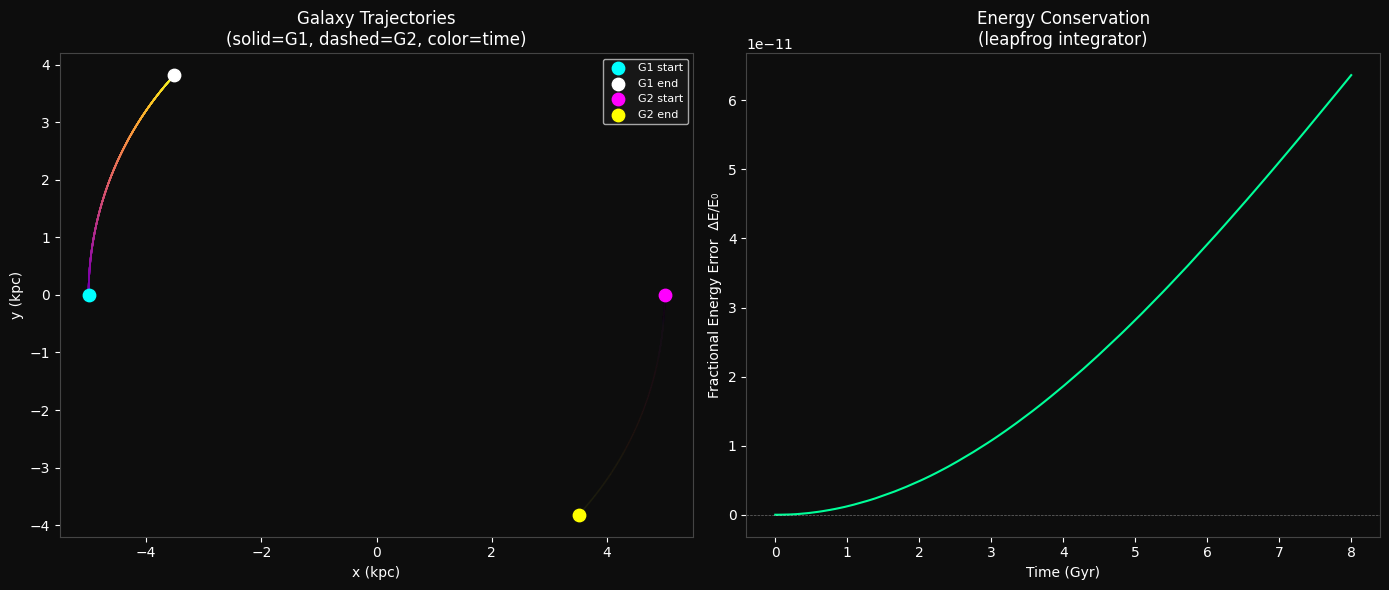

Plot saved as week1_trajectories.png


In [25]:
# ─── Visualization: Trajectories + Energy Conservation ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d0d0d')

# ── Left panel: Orbital Trajectories ──────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#0d0d0d')

# Color trajectories by time (early=dim, late=bright)
n = len(positions1)
colors = plt.cm.plasma(np.linspace(0.2, 1.0, n))

for i in range(0, n - 1, 10):
    ax1.plot(positions1[i:i+2, 0], positions1[i:i+2, 1],
             color=colors[i], linewidth=1.2, alpha=0.8)
    ax1.plot(positions2[i:i+2, 0], positions2[i:i+2, 1],
             color=colors[i], linewidth=1.2, alpha=0.8, linestyle='--')

# Mark start and end positions
ax1.scatter(*positions1[0],  color='cyan',   s=80,  zorder=5, label='G1 start')
ax1.scatter(*positions1[-1], color='white',  s=80,  zorder=5, label='G1 end')
ax1.scatter(*positions2[0],  color='magenta',s=80,  zorder=5, label='G2 start')
ax1.scatter(*positions2[-1], color='yellow', s=80,  zorder=5, label='G2 end')

ax1.set_xlabel('x (kpc)', color='white')
ax1.set_ylabel('y (kpc)', color='white')
ax1.set_title('Galaxy Trajectories\n(solid=G1, dashed=G2, color=time)', color='white')
ax1.tick_params(colors='white')
ax1.legend(fontsize=8, facecolor='#1a1a1a', labelcolor='white')
for spine in ax1.spines.values():
    spine.set_edgecolor('#444')

# ── Right panel: Energy Conservation ──────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#0d0d0d')

# Plot fractional energy error over time
E0 = energies[0]
fractional_error = (energies - E0) / abs(E0)

ax2.plot(times, fractional_error, color='#00ff99', linewidth=1.5)
ax2.axhline(0, color='white', linewidth=0.5, linestyle='--', alpha=0.4)

ax2.set_xlabel('Time (Gyr)', color='white')
ax2.set_ylabel('Fractional Energy Error  ΔE/E₀', color='white')
ax2.set_title('Energy Conservation\n(leapfrog integrator)', color='white')
ax2.tick_params(colors='white')
for spine in ax2.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('week1_trajectories.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d0d')
plt.show()
print("Plot saved as week1_trajectories.png")

In [19]:
# ─── Diagnostic ───────────────────────────────────────────────────────────────
print("First 10 positions of Galaxy 1:")
for i in range(10):
    print(f"  t={times[i]:.3f}  pos1={positions1[i]}  pos2={positions2[i]}")

print("\nLast 10 positions:")
for i in range(-10, 0):
    print(f"  t={times[i]:.3f}  pos1={positions1[i]}  pos2={positions2[i]}")

# Separation over time
separations = np.linalg.norm(positions1 - positions2, axis=1)
print(f"\nMin separation : {separations.min():.2f} kpc at t={times[separations.argmin()]:.2f}")
print(f"Max separation : {separations.max():.2f} kpc")
print(f"Final separation: {separations[-1]:.2f} kpc")

First 10 positions of Galaxy 1:
  t=0.000  pos1=[-30.   0.]  pos2=[30.  0.]
  t=0.005  pos1=[-3.00000000e+01  8.33333333e-03]  pos2=[ 3.00000000e+01 -1.66666667e-02]
  t=0.010  pos1=[-2.99999999e+01  1.66666667e-02]  pos2=[29.99999986 -0.03333333]
  t=0.015  pos1=[-2.99999998e+01  2.49999999e-02]  pos2=[29.99999969 -0.05      ]
  t=0.020  pos1=[-29.99999972   0.03333333]  pos2=[29.99999944 -0.06666667]
  t=0.025  pos1=[-29.99999957   0.04166667]  pos2=[29.99999913 -0.08333333]
  t=0.030  pos1=[-29.99999938   0.05      ]  pos2=[29.99999875 -0.1       ]
  t=0.035  pos1=[-29.99999915   0.05833333]  pos2=[29.9999983  -0.11666667]
  t=0.040  pos1=[-29.99999889   0.06666667]  pos2=[29.99999778 -0.13333333]
  t=0.045  pos1=[-29.99999859   0.075     ]  pos2=[29.99999719 -0.15      ]

Last 10 positions:
  t=14.950  pos1=[-29.88036052  24.87637433]  pos2=[ 29.76072105 -49.75274865]
  t=14.955  pos1=[-29.88029542  24.88467635]  pos2=[ 29.76059084 -49.76935269]
  t=14.960  pos1=[-29.88023031  24.8